In [1]:
import starsim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.interpolate import CubicSpline
import matplotlib.colors as mcolors


from functools import partial
from generate_colormap import *



In [2]:
def simulation_init(Q_list, spot_size_list, latitude_list, longitude_list, conf_file_path, dT_fc=None):
    """
    Iniialization of the starsim simulation for a particular set of parameters

    Params:
            -Q: facular_area_ratio
    Return:
            - ss: starsim object

    """
    
    #create the starsim object
    ss=starsim.StarSim(conf_file_path=conf_file_path)


    #set the Q parameter
    ss.facular_area_ratio=Q_list

    if dT_fc !=None:
        ss.facula_T_contrast = dT_fc

    #initialize the spot
    overlap=True

    #TODO: more modulable
    Nspots=len(spot_size_list)
    ss.spot_map=np.zeros([Nspots,8])
    for j in range(Nspots):
        ss.spot_map[j][2]=200#lifetime spot
        ss.spot_map[j][1]=0#appearance time
        ss.spot_map[j][3]=latitude_list[j]#latitude (degrees) [0,180]
        ss.spot_map[j][4]=longitude_list[j]#longitude (degrees)	[0,360]
        ss.spot_map[j][5]=spot_size_list[j]#spot size (degrees)
    return ss

In [6]:
pathdata="/home/sophie-stucki/Documents/starsim_simulations/"
path_grid="/home/sophie-stucki/starsim/starsim/gif/"
conf_file_path = "/home/sophie-stucki/starsim3/starsim/starsim_pi/conf/starsim+baroch.conf"

Q = [0]
spot_size_list = [10]
latitude_list = [90]
longitude_list = [180]
periods_nbr = 1
point_nbr = 1

ss_old = simulation_init(Q, spot_size_list, latitude_list, longitude_list, conf_file_path)
    
t=np.linspace(0,10 *periods_nbr,int(10 *periods_nbr*point_nbr))

ss_old.compute_forward(observables=['rv','lc'],t=t, w='eq_2')

5500.0
[1.4953e+13 1.1745e+13 1.2425e+12 ... 2.3468e+13 2.4587e+13 2.4654e+13]
[1.49523316e+13 1.17444677e+13 1.24248094e+12 ... 2.34675004e+13
 2.45865371e+13 2.46535440e+13]
[1.49503264e+13 1.17428710e+13 1.24242377e+12 ... 2.34660016e+13
 2.45851487e+13 2.46521759e+13]
[1.49469849e+13 1.17402100e+13 1.24232849e+12 ... 2.34635040e+13
 2.45828348e+13 2.46498960e+13]
[1.49423076e+13 1.17364853e+13 1.24219512e+12 ... 2.34600079e+13
 2.45795959e+13 2.46467048e+13]
[1.49362953e+13 1.17316975e+13 1.24202369e+12 ... 2.34555140e+13
 2.45754326e+13 2.46426027e+13]
[1.49289490e+13 1.17258474e+13 1.24181423e+12 ... 2.34500230e+13
 2.45703456e+13 2.46375905e+13]
[1.49202701e+13 1.17189360e+13 1.24156676e+12 ... 2.34435359e+13
 2.45643357e+13 2.46316690e+13]
[1.49102599e+13 1.17109646e+13 1.24128134e+12 ... 2.34360538e+13
 2.45574040e+13 2.46248393e+13]
[1.48989204e+13 1.17019345e+13 1.24095801e+12 ... 2.34275779e+13
 2.45495518e+13 2.46171025e+13]
[1.48862533e+13 1.16918473e+13 1.24059683e+12 ..

MIN:  97.16739265713053
MAX:  100.0000000000035
RANGE:  2.8326073428729615


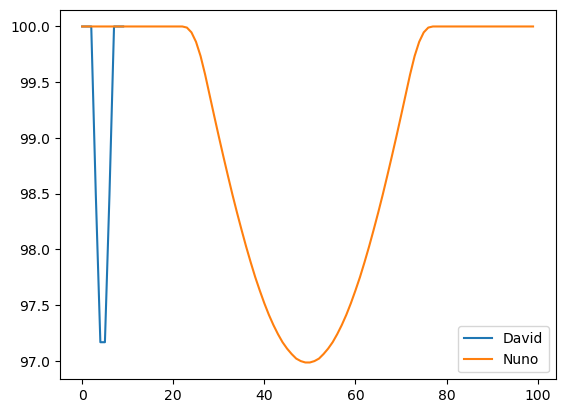

ValueError: operands could not be broadcast together with shapes (10,) (100,) 

In [7]:
obs = 'ff_ph'

lc_n = np.loadtxt(pathdata+'obs_filling_factor_quiet_new.txt')

print('MIN: ', np.min(ss_old.results[obs]))
print('MAX: ', np.max(ss_old.results[obs]))
print('RANGE: ', np.max(ss_old.results[obs])-np.min(ss_old.results[obs]))


plt.plot(ss_old.results[obs], label='David')
plt.plot(lc_n, label='Nuno')
plt.legend()
plt.show()
plt.plot((np.abs(ss_old.results[obs]-lc_n)))
plt.show()

MIN:  0.9850234471796807
MAX:  1.0
RANGE:  0.014976552820319289


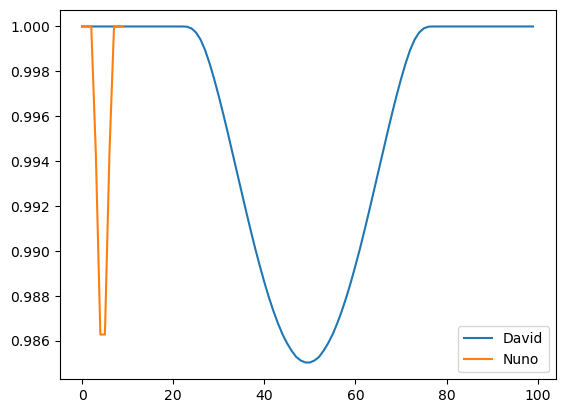

ValueError: operands could not be broadcast together with shapes (100,) (10,) 

In [5]:
obs = 'lc'

lc_n = np.loadtxt(pathdata+'obs_lc_new.txt')

print('MIN: ', np.min(ss_old.results[obs]))
print('MAX: ', np.max(ss_old.results[obs]))
print('RANGE: ', np.max(ss_old.results[obs])-np.min(ss_old.results[obs]))


plt.plot(ss_old.results[obs], label='David')
plt.plot(lc_n, label='Nuno')
plt.legend()
plt.show()
plt.plot((np.abs(ss_old.results[obs]-lc_n)))
plt.show()

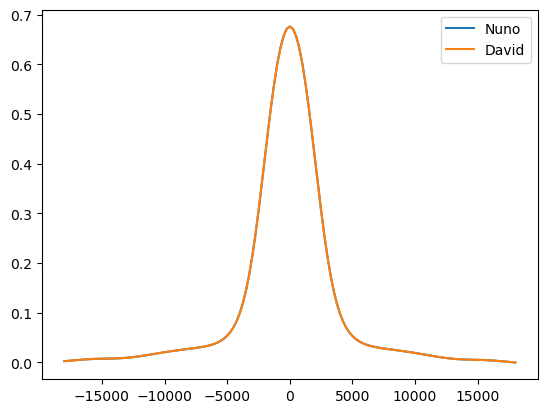

Diff:  0.0014298088311550166


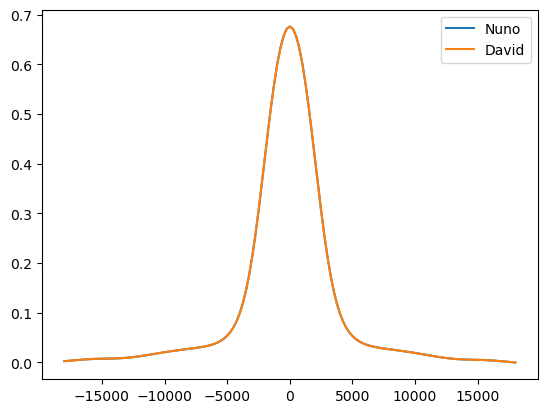

Diff:  0.0014298088311550166


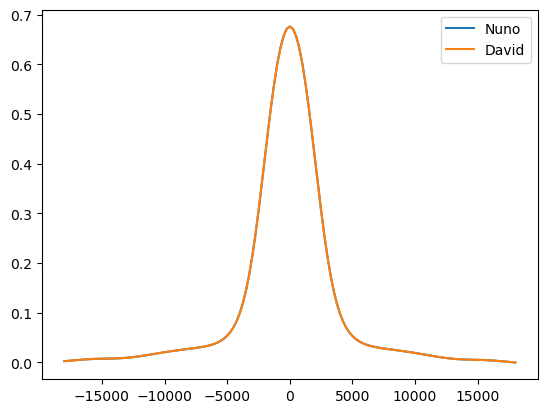

Diff:  0.0014298088311550166


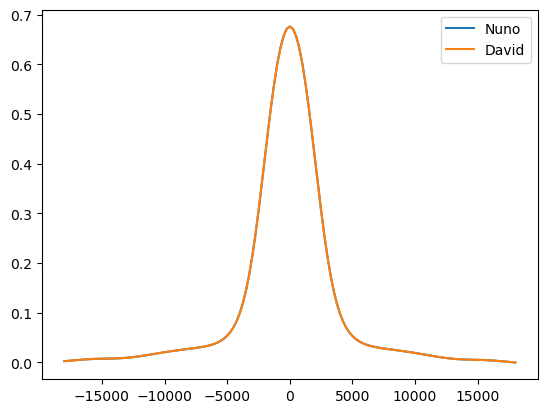

Diff:  0.0014298088311550166


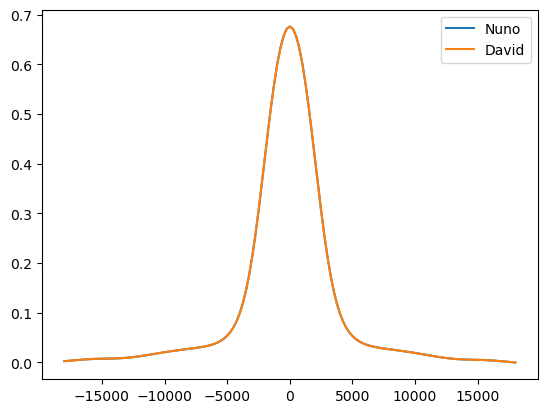

Diff:  0.0014298088311550166


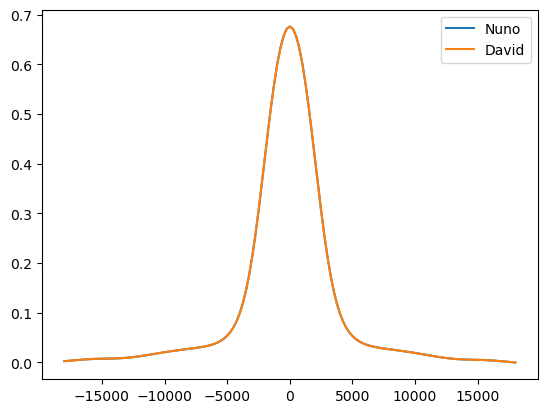

Diff:  0.0014298088311550166


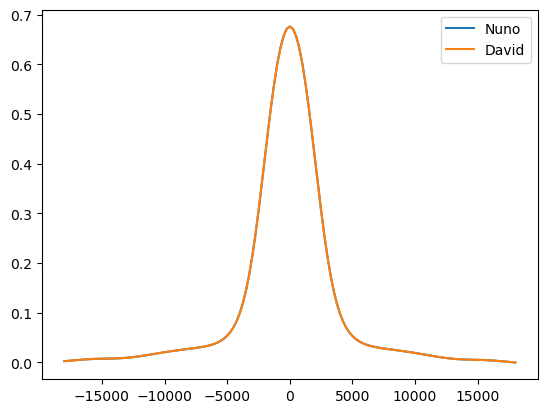

Diff:  0.0014298088311550166


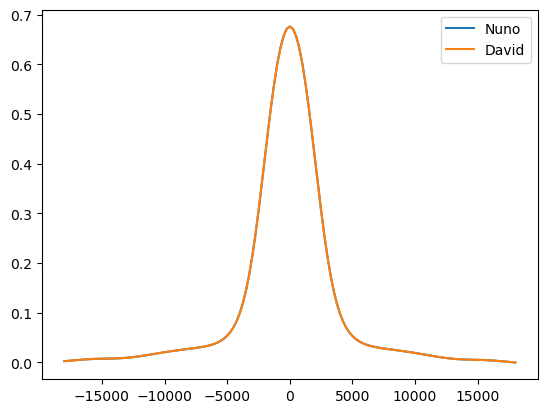

Diff:  0.0014298088311550166


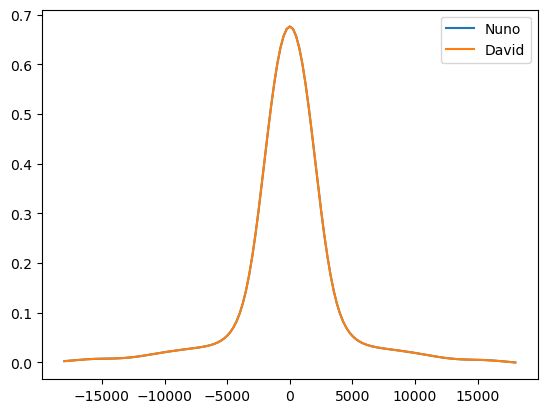

Diff:  0.0014291906119099978


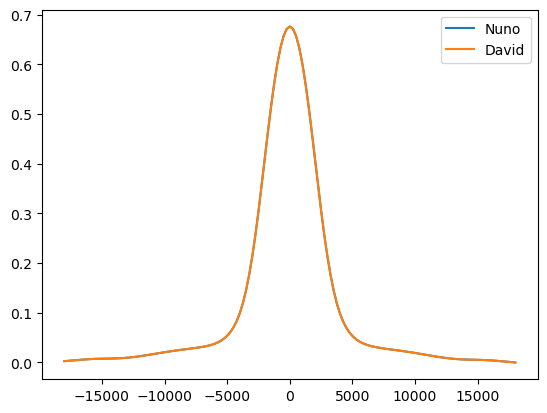

Diff:  0.0014294953944044833


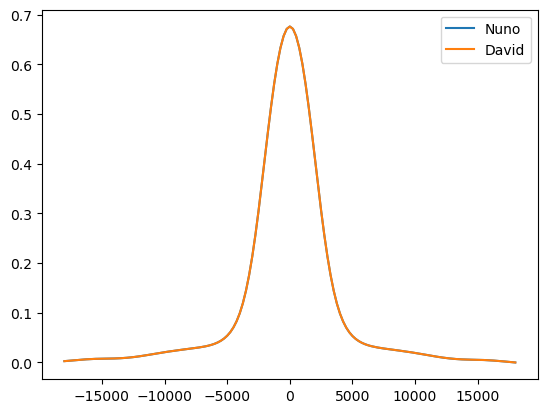

Diff:  0.001429872421888823


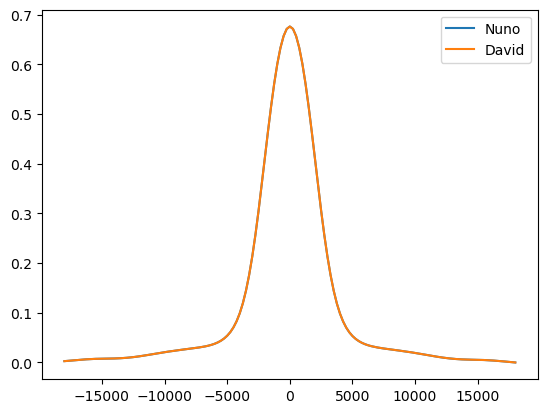

Diff:  0.0014299566693403085


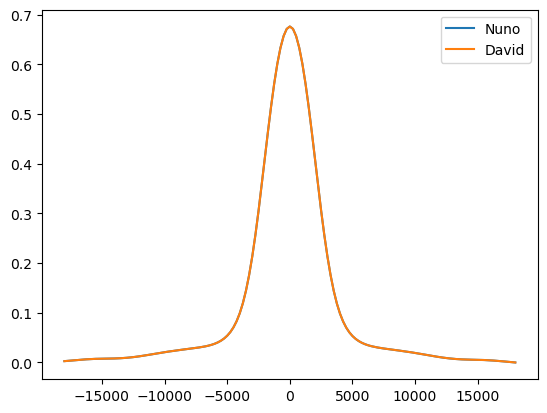

Diff:  0.0014295762276889364


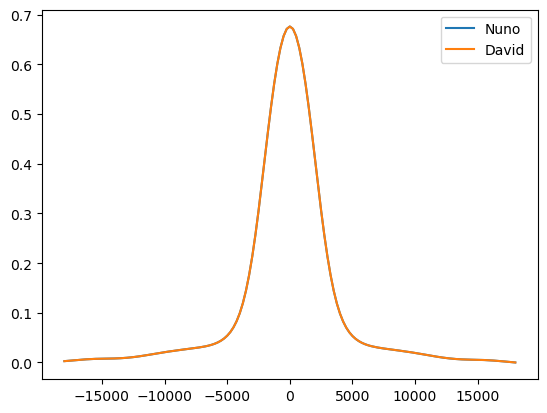

Diff:  0.0014289040445902759


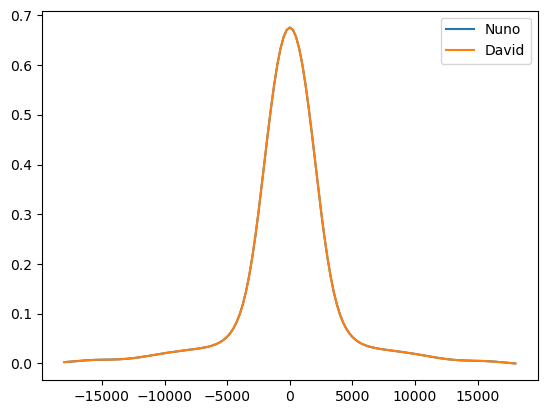

Diff:  0.001428360265451201


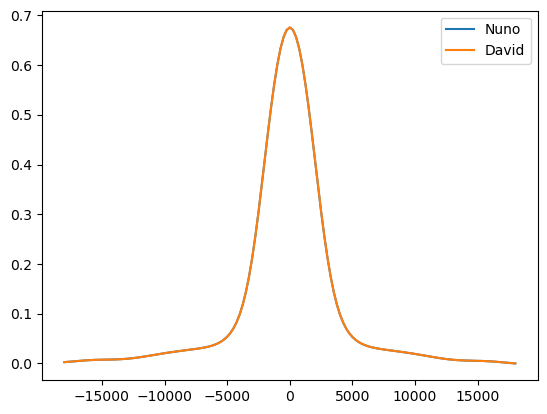

Diff:  0.0014283745206562699


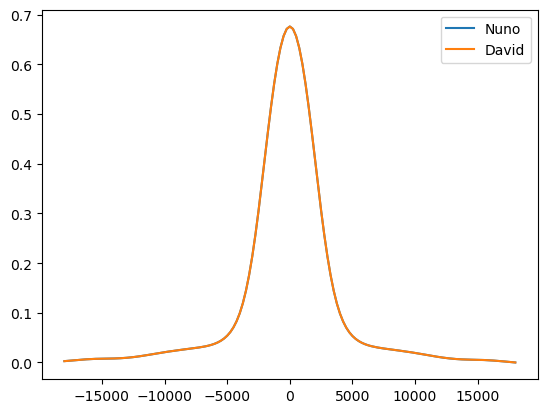

Diff:  0.0014289387420465581


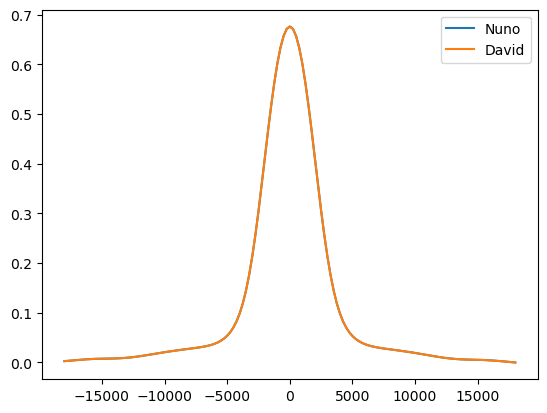

Diff:  0.00142961532104145


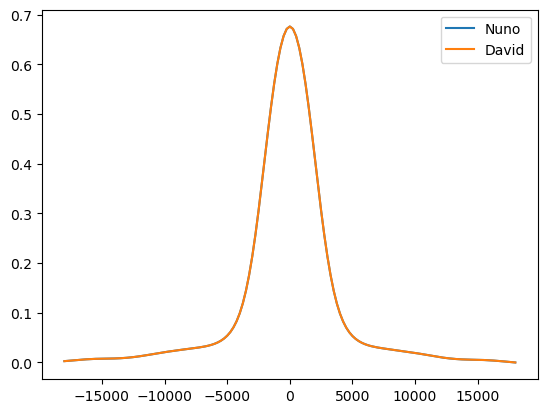

Diff:  0.0014299837789692013


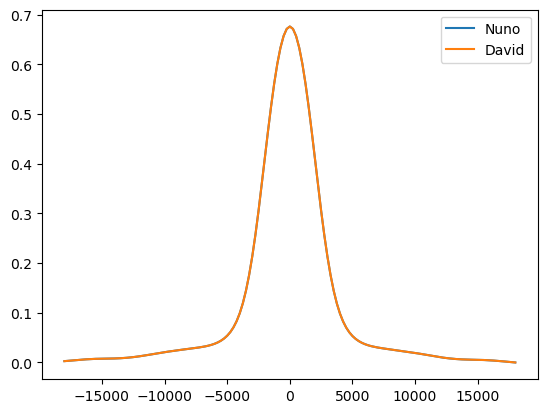

Diff:  0.0014298754332913773


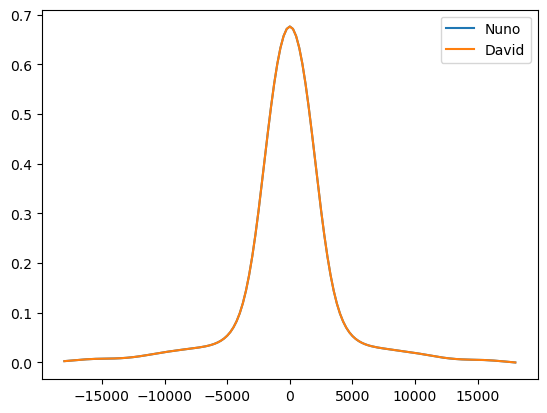

Diff:  0.0014294707917941007


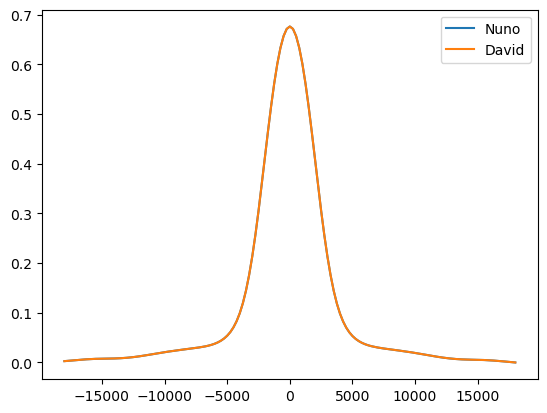

Diff:  0.0014291484870815282


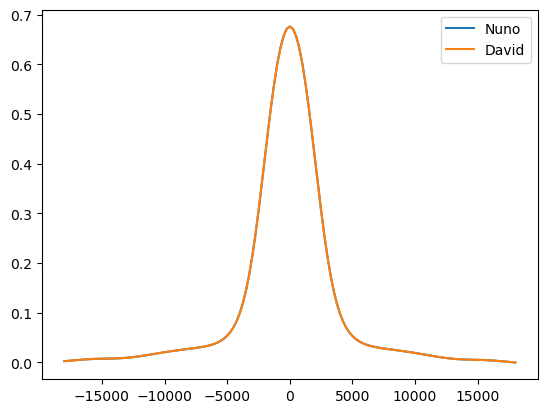

Diff:  0.0014298088311550166


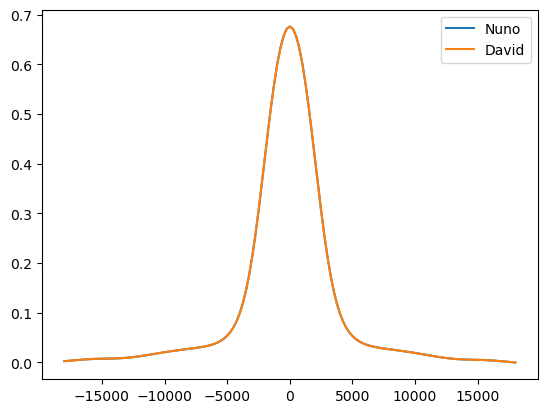

Diff:  0.0014298088311550166


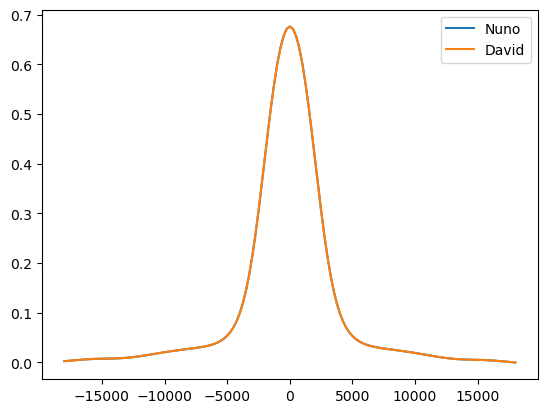

Diff:  0.0014298088311550166


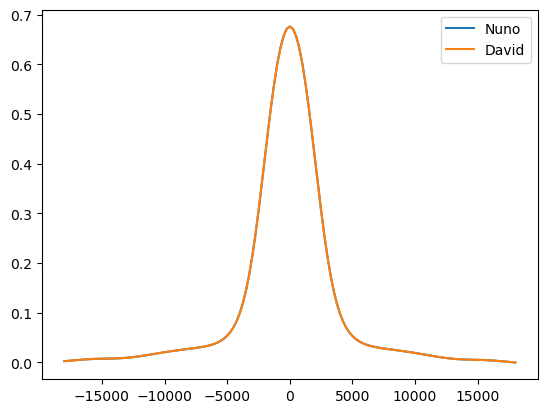

Diff:  0.0014298088311550166


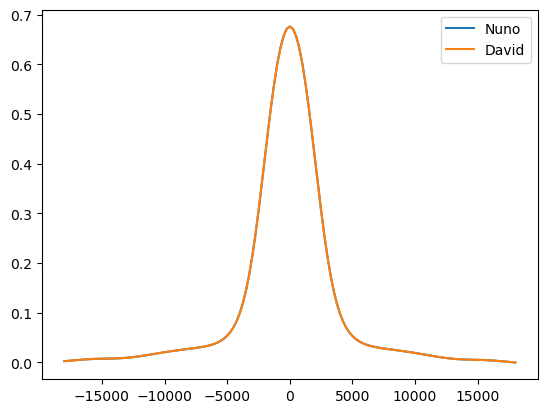

Diff:  0.0014298088311550166


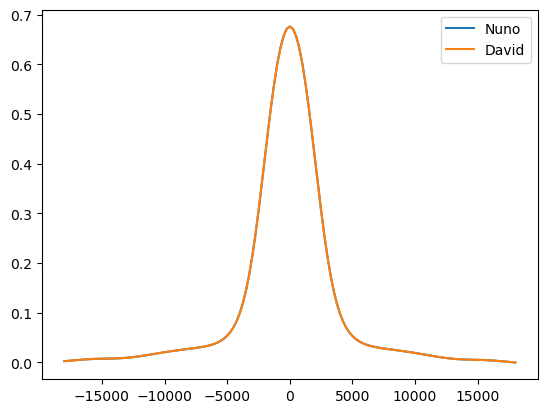

Diff:  0.0014298088311550166


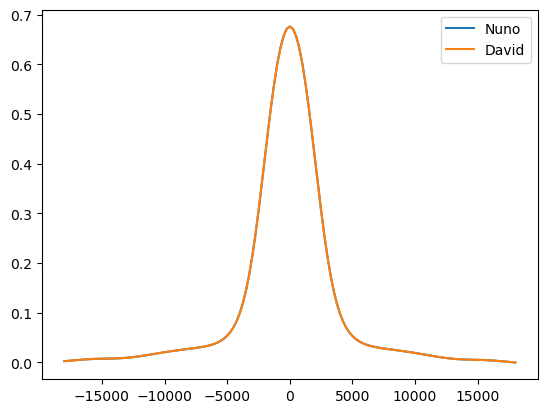

Diff:  0.0014298088311550166


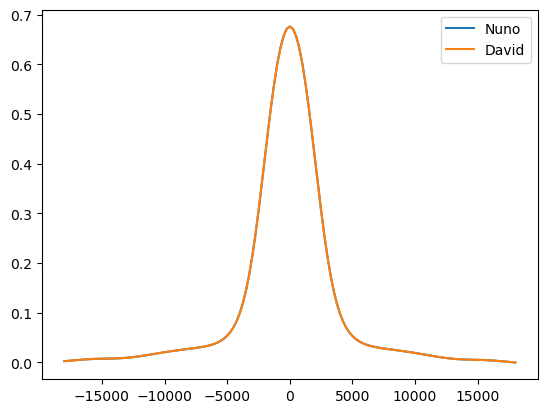

Diff:  0.0014298088311550166


In [25]:
cff_n = np.loadtxt(pathdata+'obs_ccf_new.txt')

for i in range(len(t)):
    plt.plot(cff_n[0], cff_n[1:][i], label='Nuno')
    plt.plot(ss_old.results['CCF'][0], ss_old.results['CCF'][1:][i], label='David')
    plt.legend()
    plt.show()
    print('Diff: ', np.sum(np.abs(cff_n[1:][i]-ss_old.results['CCF'][1:][i])))

In [25]:
pathdata="/home/sophie-stucki/Documents/starsim_simulations/"
limb_sp = np.loadtxt(pathdata+'obs_limb_sp_new.txt')
limb_fc = np.loadtxt(pathdata+'obs_limb_fc_new.txt')
cff_ph_n = np.loadtxt(pathdata+'obs_ccf_ph_new.txt')
cff_sp_n = np.loadtxt(pathdata+'obs_ccf_sp_new.txt')
cff_fc_n = np.loadtxt(pathdata+'obs_ccf_fc_new.txt')
cff_fc_n_old = np.loadtxt(pathdata+'obs_ccf_fc_old.txt')


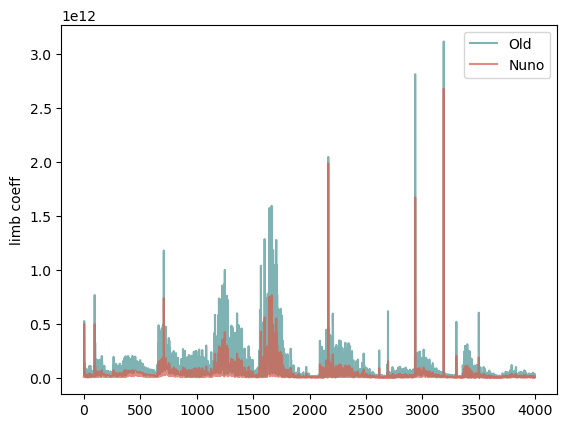

In [24]:
plt.plot(ss_old.results[obs], label='Old', color='#006666', alpha=0.5)
plt.plot(limb_fc, label='Nuno', color='#d85a4b',alpha =0.7)
plt.legend()
plt.ylabel('limb coeff')
plt.savefig(pathdata+'limb_diff.pdf', dpi=150, bbox_inches='tight')
plt.show()

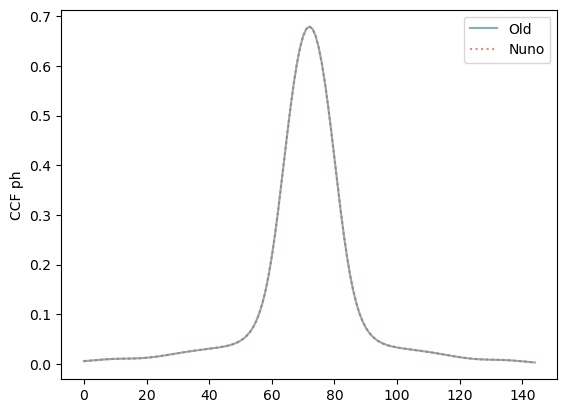

In [6]:
plt.plot(ss_old.results['ccf_ph'], label='Old', color='#006666', alpha=0.5)
plt.plot(cff_ph_n,':', label='Nuno', color='#d85a4b',alpha =0.7)
plt.legend()
plt.ylabel('CCF ph')
plt.savefig(pathdata+'ccf_ph_diff.pdf', dpi=150, bbox_inches='tight')
plt.show()

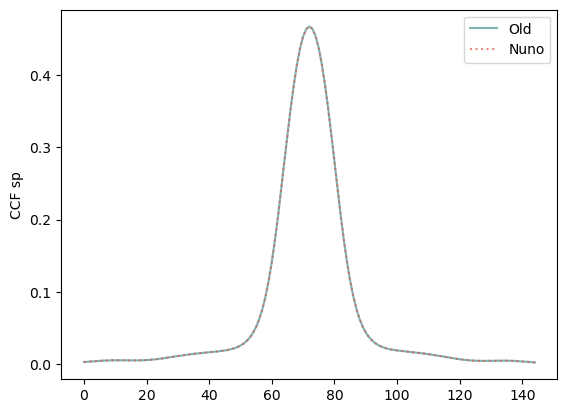

In [7]:
plt.plot(ss_old.results['ccf_sp'], label='Old', color='#006666', alpha=0.5)
plt.plot(cff_sp_n,':', label='Nuno', color='#d85a4b',alpha =0.7)
plt.legend()
plt.ylabel('CCF sp')
plt.savefig(pathdata+'ccf_sp_diff.pdf', dpi=150, bbox_inches='tight')
plt.show()

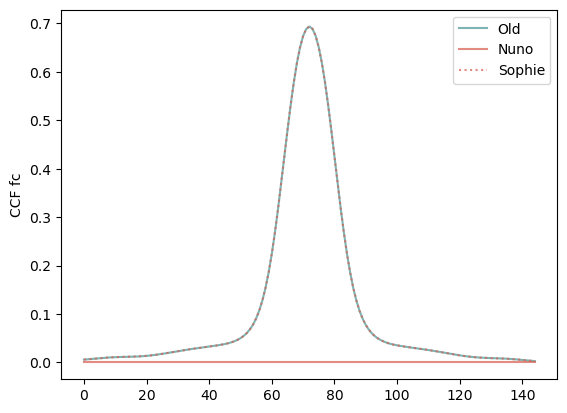

In [26]:
plt.plot(ss_old.results['ccf_fc'], label='Old', color='#006666', alpha=0.5)
plt.plot(cff_fc_n_old, label='Nuno', color='#d85a4b',alpha =0.7)
plt.plot(cff_fc_n,':', label='Sophie', color='#d85a4b',alpha =0.7)

plt.legend()
plt.ylabel('CCF fc')
plt.savefig(pathdata+'ccf_fc_diff.pdf', dpi=150, bbox_inches='tight')
plt.show()